In [49]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV
import kagglehub

In [3]:
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
print(path)


/home/alexseyka/.cache/kagglehub/datasets/yasserh/housing-prices-dataset/versions/1


In [5]:


df = pd.read_csv("Housing.csv")
print(df.shape)


(545, 13)


In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline


binary_cols = ["airconditioning" , "hotwaterheating" , "guestroom" , "basement" , "prefarea" ,"mainroad" ]
categorical_columns = ["furnishingstatus"]

preprocessor = ColumnTransformer(
    transformers=[
        ("binary", OrdinalEncoder(categories=[["no", "yes"]] * len(binary_cols)), binary_cols),
        ("categorical" , OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore"),categorical_columns)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

preprocessor.set_output(transform="pandas")

df_processed = preprocessor.fit_transform(df)

df_processed.head()

,airconditioning,hotwaterheating,guestroom,basement,prefarea,mainroad,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,price,area,bedrooms,bathrooms,stories,parking
0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,13300000,7420,4,2,3,2
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,12250000,8960,4,4,4,3
2,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,12250000,9960,3,2,2,2
3,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,12215000,7500,4,2,2,3
4,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,11410000,7420,4,1,2,2


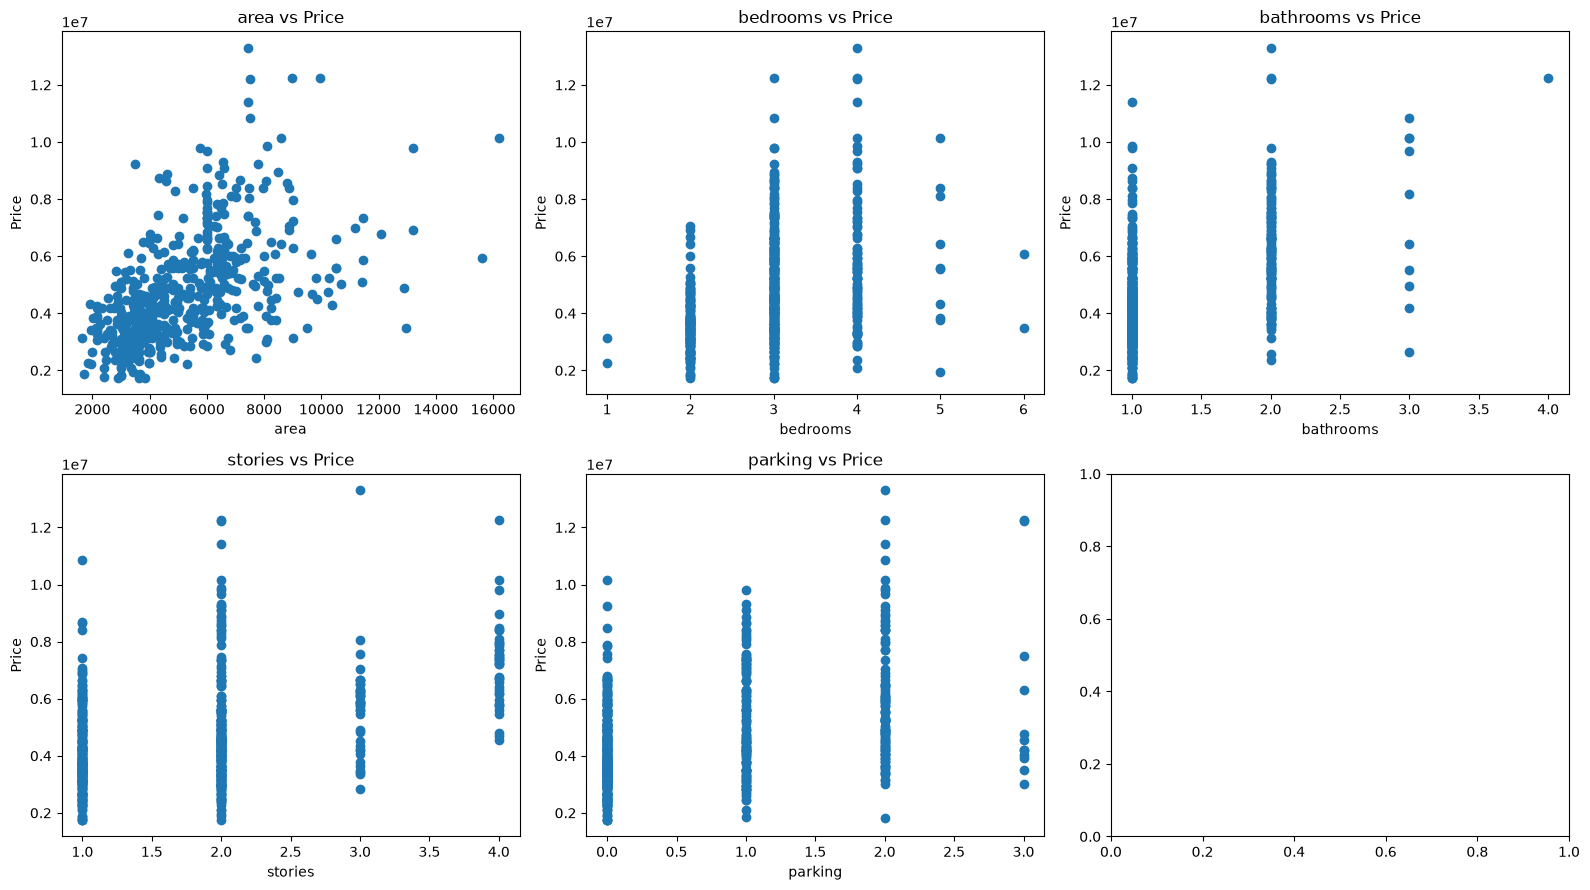

In [10]:
numeric_feature = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

fig , ax = plt.subplots(2 , 3 ,figsize=(16,9))
axes = ax.flatten()

for i , feature in enumerate(numeric_feature):
    #sns.histplot(df_processed[feature] , ax = axes[i])

    axes[i].scatter(df_processed[feature] , df_processed["price"])
    axes[i].set_title(f"{feature} vs Price")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Price")

plt.tight_layout()
plt.show()


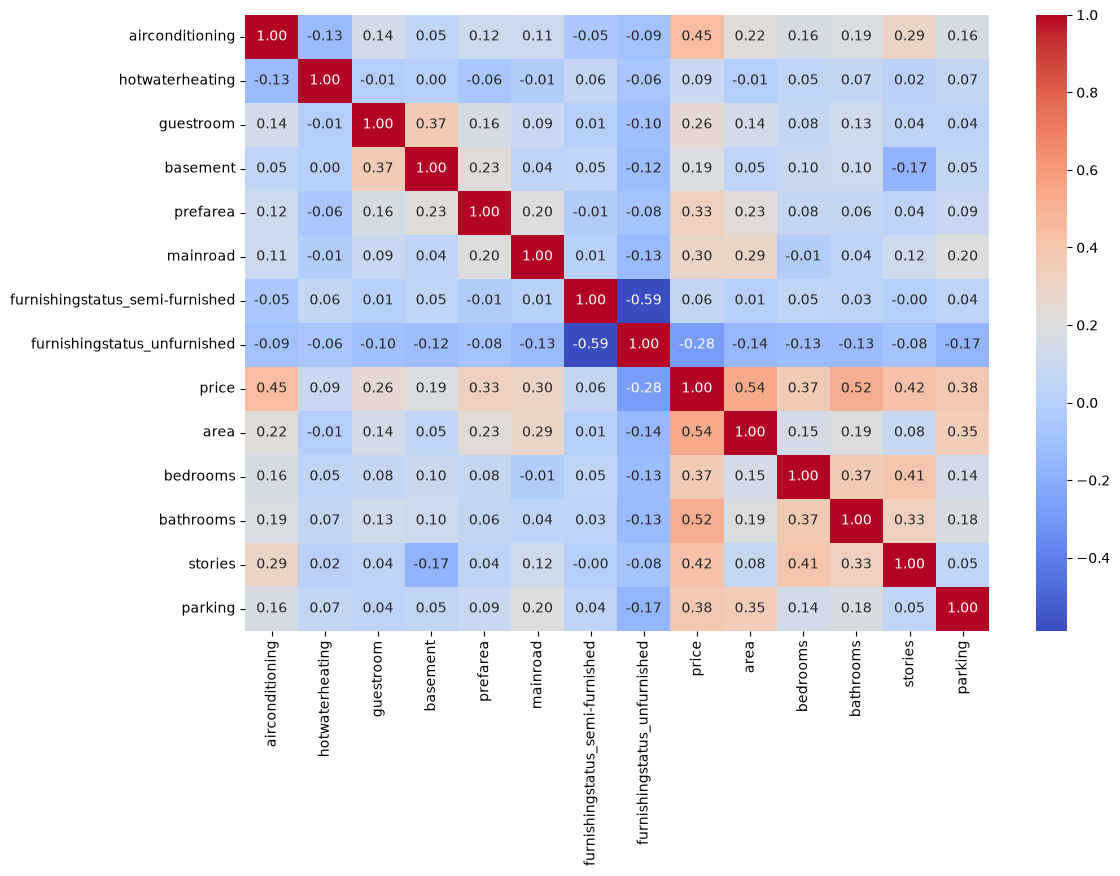

In [24]:
corr = df_processed.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [11]:
X = df_processed.drop(columns=['price'])
y = df_processed['price']

In [12]:
X.head()

,airconditioning,hotwaterheating,guestroom,basement,prefarea,mainroad,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,area,bedrooms,bathrooms,stories,parking
0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,7420,4,2,3,2
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8960,4,4,4,3
2,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,9960,3,2,2,2
3,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,7500,4,2,2,3
4,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,7420,4,1,2,2


In [13]:
y.head()


0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64

In [14]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=0)


In [15]:
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape : {y_test.shape}")


X_train shape : (436, 13)
X_test shape : (109, 13)
y_train shape : (436,)
y_test shape : (109,)


In [17]:
model = LinearRegression()
model.fit(X_train , y_train)
#^y = w*x+b
#^y = w1*x1 + w2*x2 + w3*x3 + w4*x4 + w5*x5 + b


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 871377.89,1210834.23, 402848.69,..., 996973.69, 433489.8 , 216798.69]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['airconditioning','hotwaterheating','guestroom',...,'bathrooms','stories', 'parking']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.985e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [18]:
y_pred = model.predict(X_test)

In [19]:
mse = metrics.mean_squared_error(y_test , y_pred)

print(f"MSE : {mse}")


MSE : 976484771024.5735


In [20]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mse = metrics.mean_squared_error(y_train , y_train_pred)
test_mse = metrics.mean_squared_error(y_test , y_test_pred)

print(f"Train MSE : {train_mse}")
print(f"Test MSE : {test_mse}")


Train MSE : 1157928019785.7834
Test MSE : 976484771024.5735


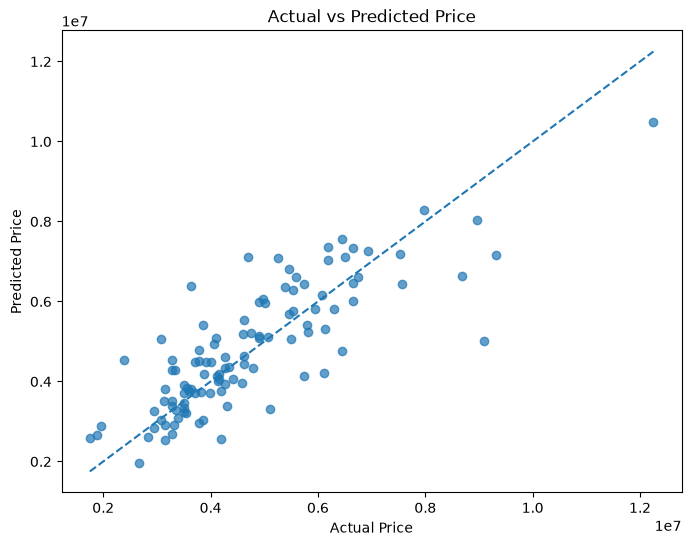

In [21]:
plt.figure(figsize=(8 , 6))
plt.scatter(y_test , y_test_pred , alpha=0.7)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")


plt.plot(
    [y_test.min() , y_test.max()],
    [y_test.min() , y_test.max()],
    linestyle='--'
)

plt.show()


In [22]:
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

print(f"Train rmse : {train_rmse}")
print(f"Test rmse : {test_rmse}")


Train rmse : 1076070.6388456956
Test rmse : 988172.4399236063


In [26]:
import catboost as ctb

model_cat = ctb.CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=0,loss_function='RMSE')

model_cat.fit(X_train , y_train)


CatBoostRegressor(depth=6, iterations=1000, learning_rate=0.1, loss_function='RMSE', verbose=0)

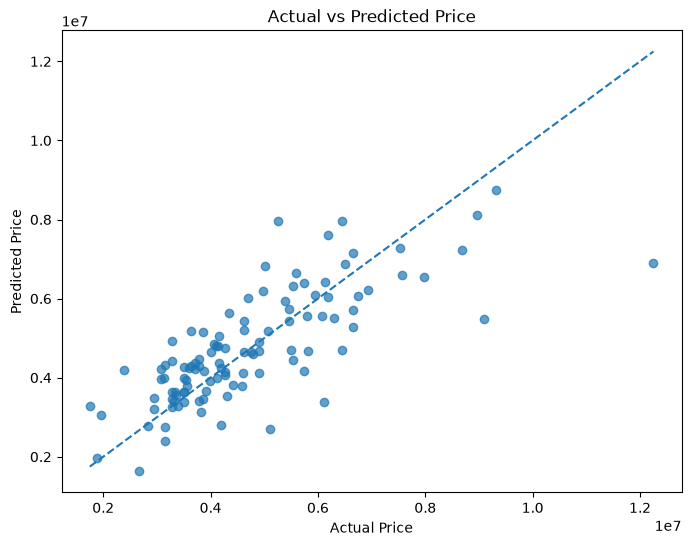

In [29]:
y_cat_test_pred = model_cat.predict(X_test)
y_cat_train_pred = model_cat.predict(X_train)

plt.figure(figsize=(8 , 6))
plt.scatter(y_test , y_cat_test_pred , alpha=0.7)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")


plt.plot(
    [y_test.min() , y_test.max()],
    [y_test.min() , y_test.max()],
    linestyle='--'
)

plt.show()



In [31]:
print(metrics.mean_squared_error(y_test , y_cat_test_pred) - metrics.mean_squared_error(y_test , y_test_pred))
print(metrics.mean_squared_error(y_train , y_cat_train_pred) - metrics.mean_squared_error(y_train , y_train_pred))

print()

231093963493.9287
-1119717629051.7266



In [41]:
gs = GridSearchCV(estimator=model_cat, param_grid={
    'iterations': [500, 1000, 1500],
    'learning_rate': [0.001,0.01, 0.05, 0.1, 0.3],
    'depth': [4, 6, 8, 10, 12]
}, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

gs.fit(X_train, y_train)

/home/alexseyka/.venvs/data-science/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostRegre...E', verbose=0)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'depth': [4, 6, ...], 'iterations': [500, 1000, ...], 'learning_rate': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose:

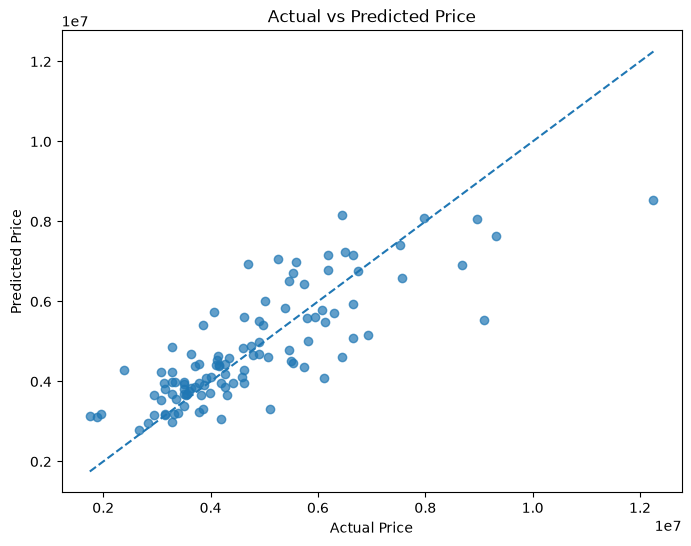

In [43]:
y_gs_test_pred = gs.predict(X_test)
y_gs_train_pred = gs.predict(X_train)

plt.figure(figsize=(8 , 6))
plt.scatter(y_test , y_gs_test_pred , alpha=0.7)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")


plt.plot(
    [y_test.min() , y_test.max()],
    [y_test.min() , y_test.max()],
    linestyle='--'
)

plt.show()



In [50]:
model_lasso = Lasso(alpha=0.1)
model_Ridge = Ridge(alpha=0.1)
model_lasso.fit(X_train , y_train)
model_Ridge.fit(X_train , y_train)


,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [51]:
print(metrics.mean_squared_error(y_test , y_gs_test_pred) - metrics.mean_squared_error(y_test , y_test_pred))
print(metrics.mean_squared_error(y_train , y_gs_train_pred) - metrics.mean_squared_error(y_train , y_train_pred))

print("Linear Regression")
print(metrics.r2_score(y_test , y_test_pred))

print("GS CatBoost Regressor")
print(metrics.r2_score(y_test , y_gs_test_pred))

print("Lasso Regression")
print(metrics.r2_score(y_test , model_lasso.predict(X_test)))
print("Ridge Regression")
print(metrics.r2_score(y_test , model_Ridge.predict(X_test)))

7277962191.265625
-233431227899.563
Linear Regression
0.6611214250980233
GS CatBoost Regressor
0.6585956863166814
Lasso Regression
0.6611216544032157
Ridge Regression
0.6616332949171577


In [23]:
new_house = X.iloc[[0]].copy()

new_house["area"] = 6000
new_house["bedrooms"] = 4
new_house["bathrooms"] = 2
new_house["stories"] = 2
new_house["parking"] = 2


predict_price = model.predict(new_house)

print(f"Predicted price : {predict_price}")

Predicted price : [7356865.98874947]
